In [2]:
import scanpy
import anndata
import matplotlib
from matplotlib import pyplot
import hdf5plugin
import numpy
import scvelo
import seaborn
import pandas
import sdevelo
import warnings

(Working on SDEvelo 0.2.12)
2026-01-20 10:47:54


In [3]:
# Suppress specific MatplotlibDeprecationWarning from the scvelo plotting module
warnings.filterwarnings("ignore", category=matplotlib.MatplotlibDeprecationWarning) # , module="scvelo.plotting.utils"

In [4]:
# Read input file
adata = scanpy.read_h5ad("/scratch/lema/m26_losu/splice_counts_mm10.h5ad")
print(adata)

AnnData object with n_obs × n_vars = 12791 × 48526
    obs: 'barcode', 'batch', 'sample', 'group', 'day'
    var: 'ensemble_ids', 'gene_symbol'
    uns: 'sample_colors'
    obsm: 'X_fdl', 'X_umap'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'


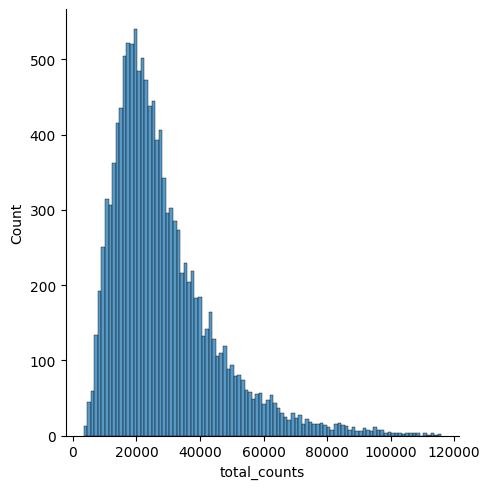

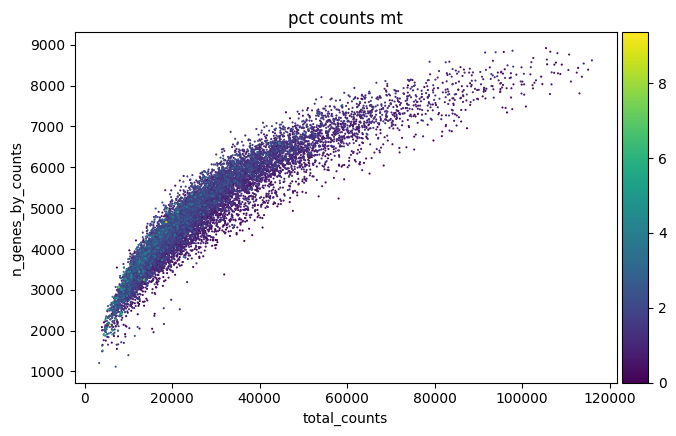

In [5]:
# Quality control

adata.var["mt"] = adata.var_names.str.startswith("mt-")
scanpy.pp.calculate_qc_metrics(
    adata, qc_vars=["mt"], inplace=True, percent_top=[], log1p=False
)

scanpy.pp.calculate_qc_metrics(
    adata, inplace=True, percent_top=[], log1p=False
)
histogram = seaborn.displot(adata.obs["total_counts"], bins=100, kde=False)
scatter = scanpy.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

View of AnnData object with n_obs × n_vars = 12791 × 48526
    obs: 'barcode', 'batch', 'sample', 'group', 'day', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'ensemble_ids', 'gene_symbol', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'sample_colors'
    obsm: 'X_fdl', 'X_umap'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'


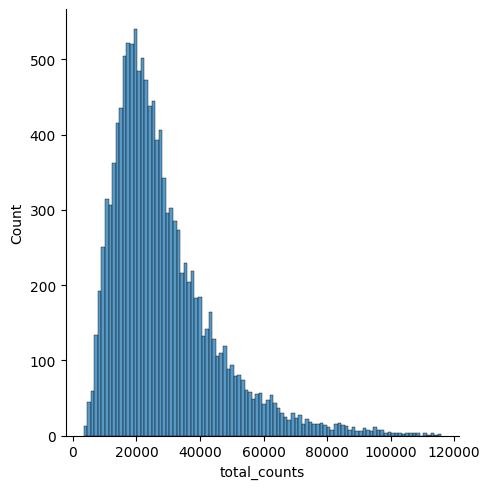

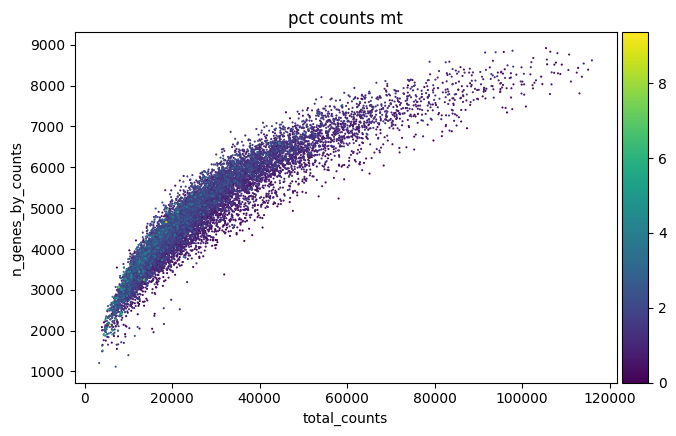

In [6]:
# Filter cells by counts per cell, total counts and percent mitochondrial
included_cells = (adata.obs["n_genes_by_counts"] >= 200)*(adata.obs['total_counts'] <= 150000)*(adata.obs['pct_counts_mt'] < 10)
adata = adata[included_cells]
print(adata)
histogram = seaborn.displot(adata.obs["total_counts"], bins=100, kde=False)
scatter = scanpy.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

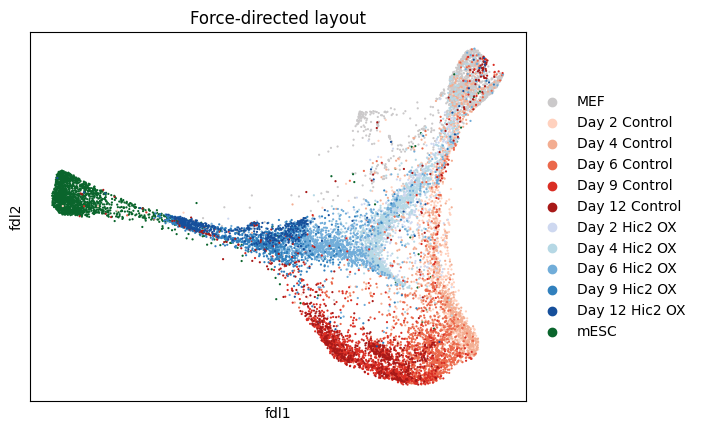

In [7]:
# Plot FDL

scanpy.pl.embedding(basis='fdl', adata=adata, color="sample", size=10, title="Force-directed layout")

In [9]:
# Define SDEvelo arguments
args = sdevelo.Config()
args.vis_key = "X_fdl"
args.vis_type_col = 'day'
args.scv_n_jobs = 20
args.n_gene = 2000

In [10]:
# Train SDEvelo model
model = sdevelo.SDENN(args, adata)
adata = model.train(100)

cpu
Filtered out 35658 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 2000 highly variable genes.
Logarithmized X.
Using scVelo version 0.3.3


/home/avesta/m26_losu/miniconda3/envs/velocity/lib/python3.12/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)


computing moments based on connectivities
    finished (0:00:02) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
5000
Epoch: 0, Loss: 0.834, alpha: 12.85, beta: 11.22, gamma: 1.13, s1: 0.010, s2: 0.012,  t_m: 0.674,  u_shift: 0.000,  s_shift: -0.012
Epoch: 50, Loss: 0.625, alpha: 3.30, beta: 6.76, gamma: 0.01, s1: 0.010, s2: 0.010,  t_m: 0.861,  u_shift: 0.000,  s_shift: -0.090


In [11]:
print(adata)

AnnData object with n_obs × n_vars = 12791 × 2000
    obs: 'barcode', 'batch', 'sample', 'group', 'day', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'latent_time'
    var: 'ensemble_ids', 'gene_symbol', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_sigma_1', 'fit_sigma_2'
    uns: 'sample_colors', 'log1p', 'pca', 'neighbors'
    obsm: 'X_fdl', 'X_umap', 'X_pca'
    varm: 'PCs'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced', 'Ms', 'Mu', 'sde_velocity', 'pred_u', 'pred_s'
    obsp: 'distances', 'connectivities'


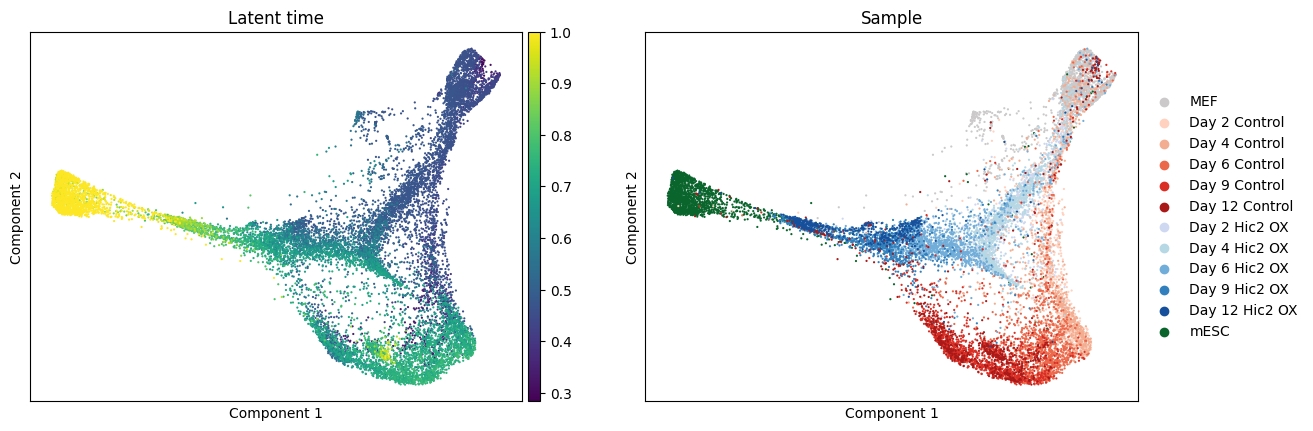

In [ ]:
# Plot latent time
axis_list = scanpy.pl.embedding(basis='fdl', adata=adata, color=["latent_time", "sample"], size=10, title=["Latent time", "Sample"], show=False)
for axis in axis_list:
    axis.set_xlabel("Component 1")
    axis.set_ylabel("Component 2")
pyplot.show()

In [13]:
# Velocity cosine correlations
scvelo.tl.velocity_graph(adata, vkey="sde_velocity", n_jobs=16)

computing velocity graph (using 16/64 cores)


  0%|          | 0/12791 [00:00<?, ?cells/s]

/home/avesta/m26_losu/miniconda3/envs/velocity/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=303799) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


    finished (0:00:16) --> added 
    'sde_velocity_graph', sparse matrix with cosine correlations (adata.uns)


computing velocity embedding
    finished (0:00:01) --> added
    'sde_velocity_fdl', embedded velocity vectors (adata.obsm)


/home/avesta/m26_losu/miniconda3/envs/velocity/lib/python3.12/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/avesta/m26_losu/miniconda3/envs/velocity/lib/python3.12/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/avesta/m26_losu/miniconda3/envs/velocity/lib/python3.12/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/avesta/m26_losu/

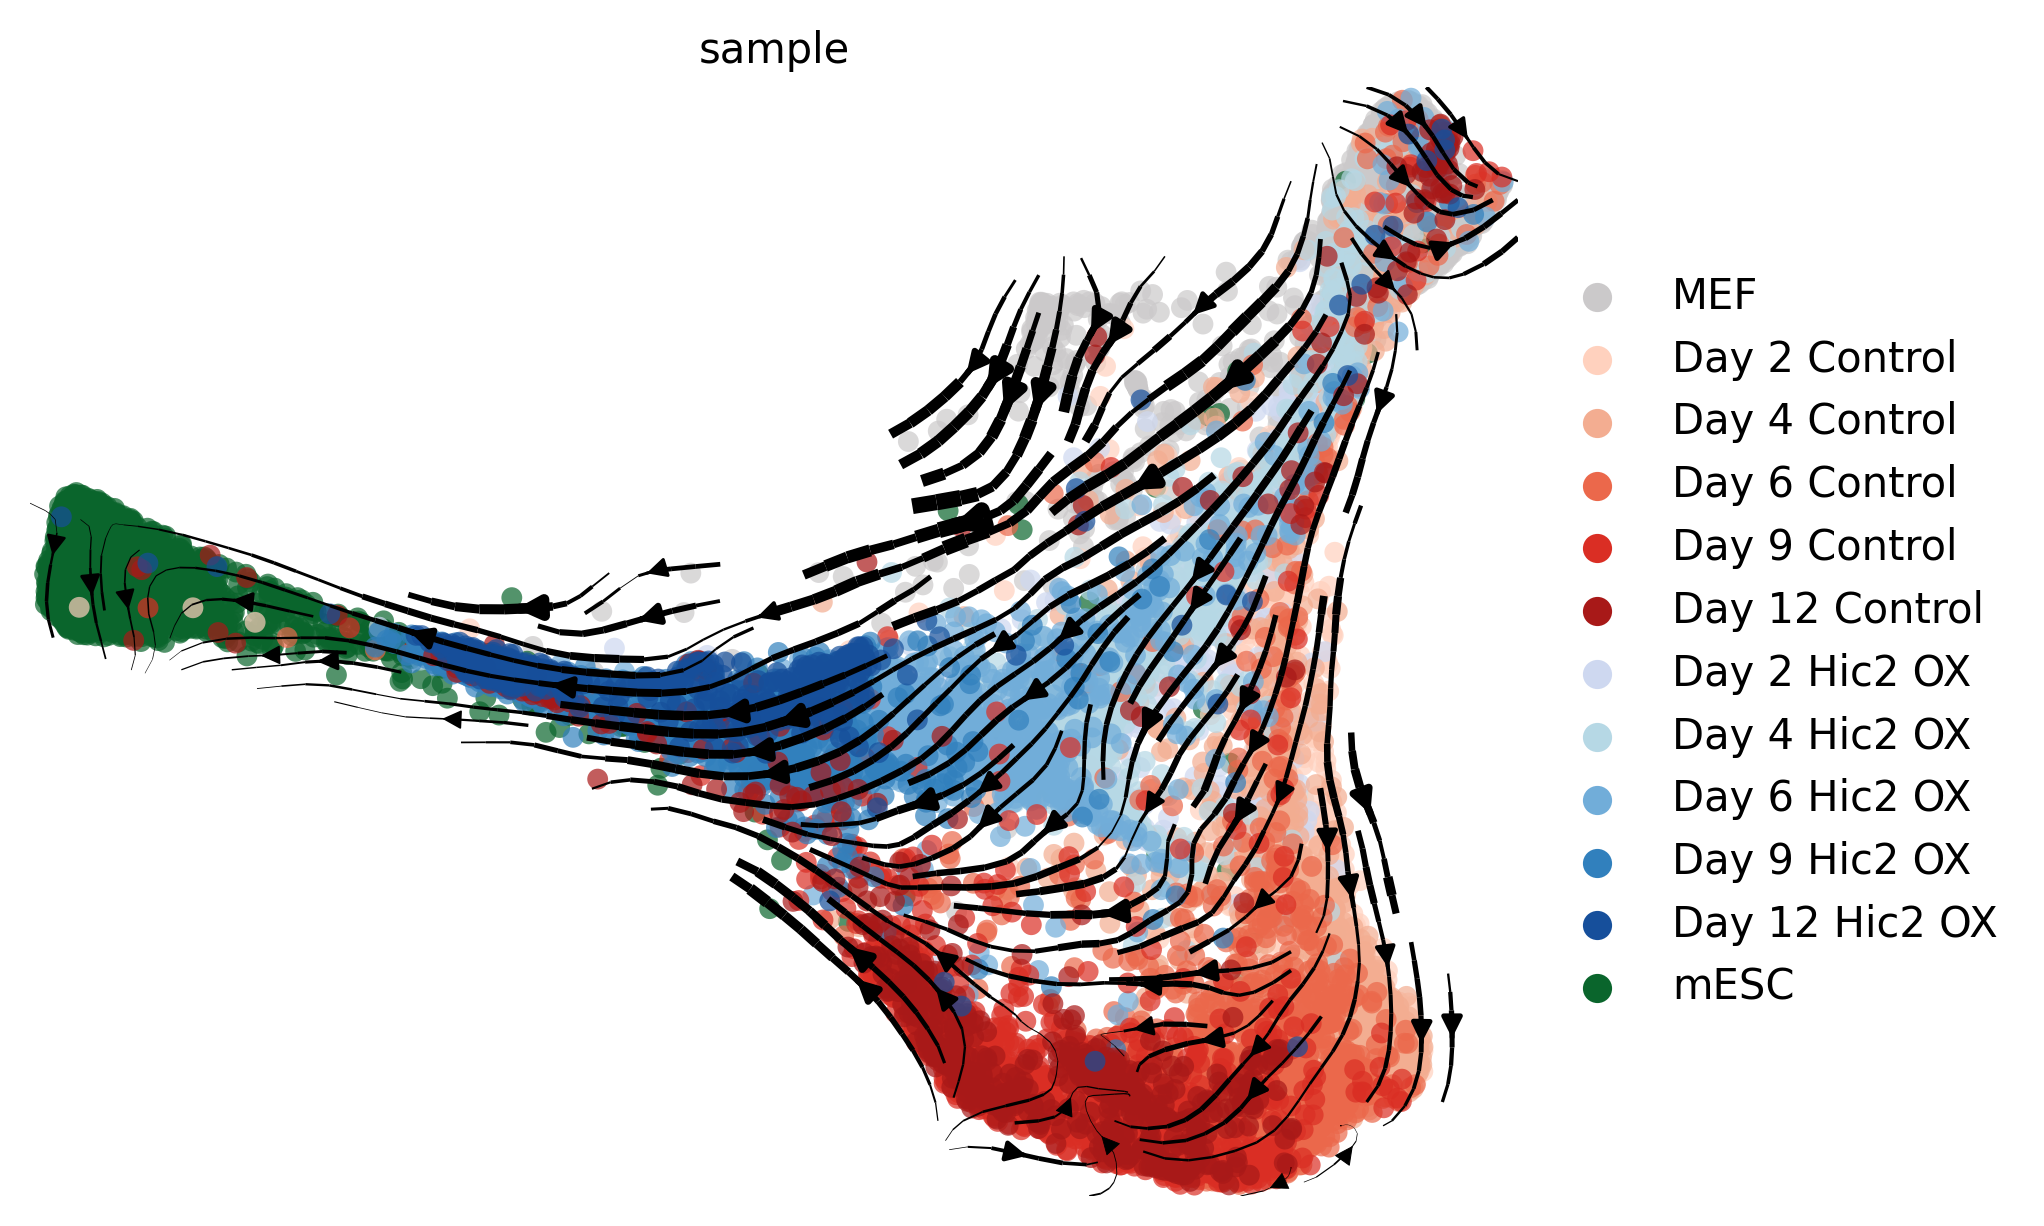

In [14]:
# Plot velocity stream
scvelo.pl.velocity_embedding_stream(adata, density=2,  linewidth=2.0, basis='fdl', dpi=300, s=100, alpha=0.7,
                                 vkey='sde_velocity', color='sample', legend_loc='right margin')

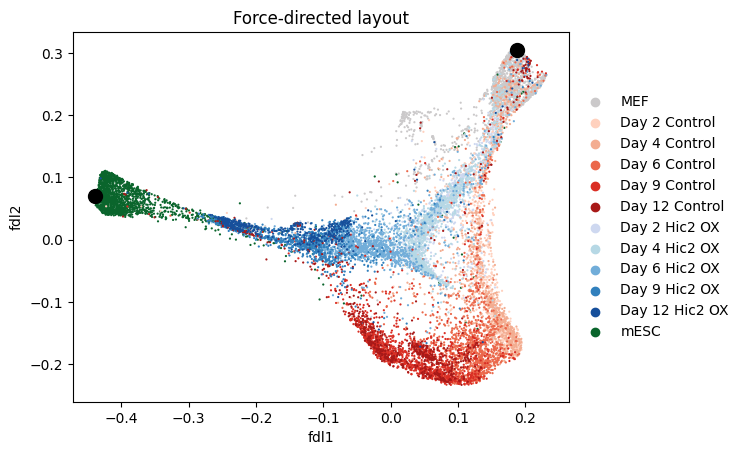

In [34]:
# Find good root and end cells

# Find root
root_filter = (adata.obs["group"]=="MEF")
# Use MEF cell with largest UMAP2, ignoring outliers with >10
root_index = numpy.argmax(adata[root_filter].obsm["X_fdl"][:,1])
root_barcode = adata[root_filter].obs.index[root_index]
adata.obs["manual_root"] = False
adata.obs["manual_root"].loc[root_barcode] = True

# Find end
end_filter = adata.obs["group"]=="mESC"
# Use mESC cell with smallest UMAP1
end_index = numpy.argmin(adata[end_filter].obsm["X_fdl"][:,0])
end_barcode = adata[end_filter].obs.index[end_index]
adata.obs["manual_end"] = False
adata.obs["manual_end"].loc[end_barcode] = True

ax = scanpy.pl.embedding(basis='fdl', adata=adata, color="sample", size=10, title="Force-directed layout", show=False)

# Plot UMAP
ax.scatter(*adata[adata.obs["manual_end"]].obsm["X_fdl"][0], marker="o", s=100, color="black")
ax.scatter(*adata[adata.obs["manual_root"]].obsm["X_fdl"][0], marker="o", s=100, color="black")
ax.yaxis.set_major_locator(matplotlib.ticker.AutoLocator())
ax.xaxis.set_major_locator(matplotlib.ticker.AutoLocator())

pyplot.show()

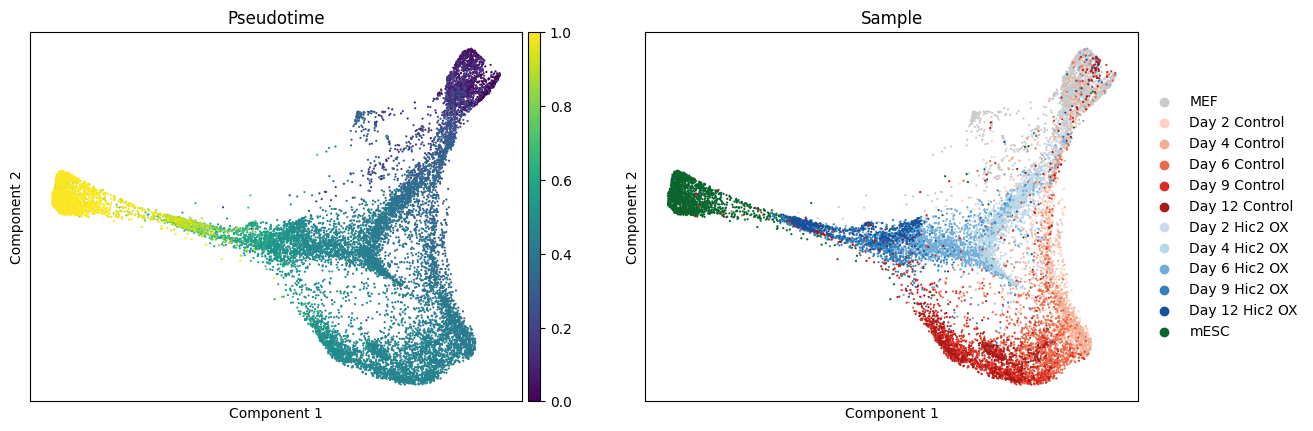

In [38]:
# Pseudotime
global_root_index = numpy.argmax(adata.obs.index == root_barcode)
global_end_index = numpy.argmax(adata.obs.index == end_barcode)

scvelo.tl.velocity_pseudotime(adata, root_key=global_root_index, end_key=global_end_index, vkey="sde_velocity")

# Plot velocities colored by latent time
axis_list = scanpy.pl.embedding(basis='fdl', adata=adata, color=["sde_velocity_pseudotime", "sample"], size=10, title=["Pseudotime", "Sample"], show=False)
for axis in axis_list:
    axis.set_xlabel("Component 1")
    axis.set_ylabel("Component 2")
pyplot.show()

In [46]:
scanpy.pp.neighbors(adata, n_neighbors=15, n_pcs=50) # Uses PCA of X, can be adapted to use UMAP or FDL

In [47]:
# PAGA
adata.uns['neighbors']['distances'] = adata.obsp['distances']
adata.uns['neighbors']['connectivities'] = adata.obsp['connectivities']

scanpy.tl.diffmap(adata)
scanpy.pp.neighbors(adata, n_neighbors=10, use_rep='X_diffmap')
scanpy.tl.draw_graph(adata, color="sample", n_jobs=20)

In [58]:
print(adata)
adata.uns["velocity_graph"] = adata.uns["sde_velocity_graph"]
adata.obs["velocity_pseudotime"] = adata.obs["sde_velocity_pseudotime"]

AnnData object with n_obs × n_vars = 12791 × 2000
    obs: 'barcode', 'batch', 'sample', 'group', 'day', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'latent_time', 'sde_velocity_self_transition', 'root_cells', 'end_points', 'sde_velocity_pseudotime', 'manual_root', 'manual_end'
    var: 'ensemble_ids', 'gene_symbol', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_sigma_1', 'fit_sigma_2'
    uns: 'sample_colors', 'log1p', 'pca', 'neighbors', 'sde_velocity_graph', 'sde_velocity_graph_neg', 'sde_velocity_params', 'paga', 'sample_sizes', 'draw_graph', 'diffmap_evals', 'velocity_graph'
    obsm: 'X_fdl', 'X_umap', 'X_pca', 'sde_velocity_fdl', 'X_draw_graph_fa', 'X_diffmap'
    varm: 'PCs'
    layers: 'ambiguous', 'mat

In [57]:
print(adata.uns["paga"])

{'connectivities': <Compressed Sparse Row sparse matrix of dtype 'float64'
	with 132 stored elements and shape (12, 12)>, 'connectivities_tree': <Compressed Sparse Row sparse matrix of dtype 'float64'
	with 11 stored elements and shape (12, 12)>, 'groups': 'sample', 'pos': array([[ 0.1720483468,  0.2389087618],
       [ 0.1470335974, -0.0299405055],
       [ 0.1512591106, -0.0861523423],
       [ 0.122588404 , -0.1763039304],
       [ 0.0306796211, -0.1806672967],
       [ 0.0320527945, -0.1700818312],
       [ 0.074636439 ,  0.0313599966],
       [ 0.0613745345,  0.0274089806],
       [-0.027687924 , -0.0075080261],
       [-0.1233831503,  0.0022829689],
       [-0.1424948079,  0.020417271 ],
       [-0.4067182031,  0.0618959224]]), 'transitions_confidence': <Compressed Sparse Column sparse matrix of dtype 'float64'
	with 66 stored elements and shape (12, 12)>}


/home/avesta/m26_losu/miniconda3/envs/velocity/lib/python3.12/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/avesta/m26_losu/miniconda3/envs/velocity/lib/python3.12/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/avesta/m26_losu/miniconda3/envs/velocity/lib/python3.12/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/avesta/m26_losu/

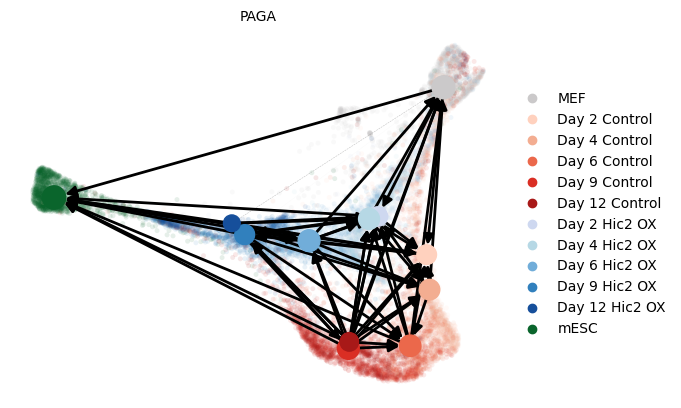

In [59]:
# scanpy.tl.paga(adata, groups='sample', use_rna_velocity=True)
# scvelo.tl.paga(adata, groups="sample", vkey="sde_velocity")
scvelo.pl.paga(adata, basis='fdl', size=50, alpha=.1, min_edge_width=2, node_size_scale=1.5, title='PAGA', vkey="sde_velocity")

In [50]:
print(adata)

AnnData object with n_obs × n_vars = 12791 × 2000
    obs: 'barcode', 'batch', 'sample', 'group', 'day', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'latent_time', 'sde_velocity_self_transition', 'root_cells', 'end_points', 'sde_velocity_pseudotime', 'manual_root', 'manual_end'
    var: 'ensemble_ids', 'gene_symbol', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_sigma_1', 'fit_sigma_2'
    uns: 'sample_colors', 'log1p', 'pca', 'neighbors', 'sde_velocity_graph', 'sde_velocity_graph_neg', 'sde_velocity_params', 'paga', 'sample_sizes', 'draw_graph', 'diffmap_evals'
    obsm: 'X_fdl', 'X_umap', 'X_pca', 'sde_velocity_fdl', 'X_draw_graph_fa', 'X_diffmap'
    varm: 'PCs'
    layers: 'ambiguous', 'matrix', 'spliced', '

In [61]:
# Save adata object
adata.write_h5ad(
    "/scratch/lema/m26_losu/velocity_sdevelo.h5ad",
    compression=hdf5plugin.FILTERS["zstd"]
)